In [21]:
# from LadrunoGraphStyle import set_default_plot_params, main_colors
# set_default_plot_params()

In [22]:
from fem import (
    # Core
    Material,
    # Sections
    Membrane,
    # Gmsh tools
    GMSHtools,
    # Model
    FEMModel,
    # Elements
    CST, LST, Quad4, Quad9,
    # Units
    kgf, tf, kN, MPa, GPa, kg, g, cm, m, mm, N,
    # Parameters
    globalParameters,
)


import os
import numpy as np
import matplotlib.pyplot as plt
import gmsh
np.set_printoptions(suppress=True, precision=6, linewidth=400)

In [23]:
globalParameters['nDoF'] = 2
globalParameters['nDIM'] = 2

In [24]:
# General model parameters
output_path = os.getcwd()
mesh_name = 'wrench'
output_file = os.path.join(output_path, mesh_name + '.msh')

if not os.path.exists(output_path):
    os.makedirs(output_path)

In [25]:
gmsh.initialize()
gmsh.model.add(output_file)
import math

# Parameters
head_diameter_left   = 32
head_diameter_right  = 29
head_distance        = 110
ring_distance        = 55
ring_diameter        = 6.5
handle_width         = 11
fillet_radius_left   = 47
fillet_radius_right  = 23
inner_radius_left    = 13
inner_radius_right   = 9
offset_left          = 17
offset_right         = 13
delta_x_inner        = 6
delta_y_inner        = 2

head_radius_left  = head_diameter_left  / 2.0
head_radius_right = head_diameter_right / 2.0

# Central ring
p1 = gmsh.model.geo.addPoint(head_distance/2 - ring_distance/2,  0,                0, 1)
p2 = gmsh.model.geo.addPoint(head_distance/2 - ring_distance/2,  ring_diameter/2,  0, 1)
p3 = gmsh.model.geo.addPoint(head_distance/2 - ring_distance/2, -ring_diameter/2,  0, 1)
p4 = gmsh.model.geo.addPoint(head_distance/2 + ring_distance/2,  0,                0, 1)
p5 = gmsh.model.geo.addPoint(head_distance/2 + ring_distance/2,  ring_diameter/2,  0, 1)
p6 = gmsh.model.geo.addPoint(head_distance/2 + ring_distance/2, -ring_diameter/2,  0, 1)

l1   = gmsh.model.geo.addLine(p2, p5)
l2   = gmsh.model.geo.addLine(p6, p3)
arc1 = gmsh.model.geo.addCircleArc(p3, p1, p2)
arc2 = gmsh.model.geo.addCircleArc(p5, p4, p6)

# Handle geometry
half_width = handle_width / 2.0

R1 = head_radius_left
R2 = fillet_radius_left
dx_left   = math.sqrt(R1**2 + 2*R2*(R1 - half_width) - half_width**2)
sin_theta = dx_left / (R1 + R2)
cos_theta = (half_width + R2) / (R1 + R2)
x_left    = R1 * sin_theta
y_left    = R1 * cos_theta

R1 = head_radius_right
R2 = fillet_radius_right
dx_right  = math.sqrt(R1**2 + 2*R2*(R1 - half_width) - half_width**2)
sin_theta = dx_right / (R1 + R2)
cos_theta = (half_width + R2) / (R1 + R2)
x_right   = R1 * sin_theta
y_right   = R1 * cos_theta

pm1  = gmsh.model.geo.addPoint(x_left,                   y_left,                           0, 1)
pm2  = gmsh.model.geo.addPoint(x_left,                  -y_left,                           0, 1)
pm3  = gmsh.model.geo.addPoint(dx_left,                  half_width,                       0, 1)
pm4  = gmsh.model.geo.addPoint(dx_left,                 -half_width,                       0, 1)
pm5  = gmsh.model.geo.addPoint(head_distance - dx_right, half_width,                       0, 1)
pm6  = gmsh.model.geo.addPoint(head_distance - dx_right,-half_width,                       0, 1)
pm7  = gmsh.model.geo.addPoint(head_distance - x_right,  y_right,                          0, 1)
pm8  = gmsh.model.geo.addPoint(head_distance - x_right, -y_right,                          0, 1)
pm9  = gmsh.model.geo.addPoint(dx_left,                  half_width  + fillet_radius_left,  0, 1)
pm10 = gmsh.model.geo.addPoint(dx_left,                 -half_width  - fillet_radius_left,  0, 1)
pm11 = gmsh.model.geo.addPoint(head_distance - dx_right, half_width  + fillet_radius_right, 0, 1)
pm12 = gmsh.model.geo.addPoint(head_distance - dx_right,-half_width  - fillet_radius_right, 0, 1)
pc1  = gmsh.model.geo.addPoint(0,             0, 0, 1)
pc2  = gmsh.model.geo.addPoint(head_distance, 0, 0, 1)

lm1   = gmsh.model.geo.addLine(pm3, pm5)
lm2   = gmsh.model.geo.addLine(pm4, pm6)
arc_m1 = gmsh.model.geo.addCircleArc(pm1, pm9,  pm3)
arc_m2 = gmsh.model.geo.addCircleArc(pm2, pm10, pm4)
arc_m3 = gmsh.model.geo.addCircleArc(pm5, pm11, pm7)
arc_m4 = gmsh.model.geo.addCircleArc(pm6, pm12, pm8)
arc_m5 = gmsh.model.geo.addCircleArc(pm1, pc1,  pm2)
arc_m6 = gmsh.model.geo.addCircleArc(pm7, pc2,  pm8)

# Left head
alpha_left = math.asin((offset_left / 2.0) / head_radius_left)
theta      = math.atan(delta_y_inner / delta_x_inner)

pi1 = gmsh.model.geo.addPoint(-head_radius_left * math.cos(alpha_left - theta),  head_radius_left * math.sin(alpha_left - theta),  0, 1)
pi2 = gmsh.model.geo.addPoint(-head_radius_left * math.cos(-alpha_left - theta), head_radius_left * math.sin(-alpha_left - theta), 0, 1)
pi3 = gmsh.model.geo.addPoint(-head_radius_left * math.cos(alpha_left - theta)  + offset_left * math.cos(theta), head_radius_left * math.sin(alpha_left - theta)  + offset_left * math.sin(theta), 0, 1)
pi4 = gmsh.model.geo.addPoint(-head_radius_left * math.cos(-alpha_left - theta) + offset_left * math.cos(theta), head_radius_left * math.sin(-alpha_left - theta) + offset_left * math.sin(theta), 0, 1)
pc3 = gmsh.model.geo.addPoint(-delta_x_inner, -delta_y_inner, 0, 1)

li1    = gmsh.model.geo.addLine(pi1, pi3)
li2    = gmsh.model.geo.addLine(pi2, pi4)
arc_i1 = gmsh.model.geo.addCircleArc(pm1, pc1, pi1)
arc_i2 = gmsh.model.geo.addCircleArc(pi2, pc1, pm2)
arc_i3 = gmsh.model.geo.addCircleArc(pi4, pc3, pi3)

# Right head
alpha_right = math.asin((offset_right / 2.0) / head_radius_right)

pi5 = gmsh.model.geo.addPoint(head_distance + head_radius_right * math.cos(alpha_right + theta),  head_radius_right * math.sin(alpha_right + theta),  0, 1)
pi6 = gmsh.model.geo.addPoint(head_distance + head_radius_right * math.cos(theta - alpha_right),  head_radius_right * math.sin(theta - alpha_right),  0, 1)
pi7 = gmsh.model.geo.addPoint(head_distance + head_radius_right * math.cos(alpha_right + theta) - offset_right * math.cos(theta), head_radius_right * math.sin(alpha_right + theta) - offset_right * math.sin(theta), 0, 1)
pi8 = gmsh.model.geo.addPoint(head_distance + head_radius_right * math.cos(theta - alpha_right) - offset_right * math.cos(theta), head_radius_right * math.sin(theta - alpha_right) - offset_right * math.sin(theta), 0, 1)
pc4 = gmsh.model.geo.addPoint(head_distance + delta_x_inner, delta_y_inner, 0, 1)

li3    = gmsh.model.geo.addLine(pi7, pi5)
li4    = gmsh.model.geo.addLine(pi8, pi6)
arc_i4 = gmsh.model.geo.addCircleArc(pm7, pc2, pi5)
arc_i5 = gmsh.model.geo.addCircleArc(pi6, pc2, pm8)
arc_i6 = gmsh.model.geo.addCircleArc(pi8, pc4, pi7)

# Surfaces
loop1    = gmsh.model.geo.addCurveLoop([-arc1, -l2, -arc2, -l1])
surface1 = gmsh.model.geo.addPlaneSurface([loop1])

loop2    = gmsh.model.geo.addCurveLoop([-arc_m1, -lm1, -arc_m3, -arc_m6, arc_m4, lm2, arc_m2, arc_m5])
loop3    = gmsh.model.geo.addCurveLoop([l1, arc2, l2, arc1])
surface2 = gmsh.model.geo.addPlaneSurface([loop2, loop3])

loop4    = gmsh.model.geo.addCurveLoop([li1, -arc_i3, -li2, arc_i2, -arc_m5, arc_i1])
surface3 = gmsh.model.geo.addPlaneSurface([loop4])

loop5    = gmsh.model.geo.addCurveLoop([-arc_i4, li3, arc_i6, -li4, -arc_i5, arc_m6])
surface4 = gmsh.model.geo.addPlaneSurface([loop5])

# Mesh settings
def all_quads():
    gmsh.model.geo.synchronize()
    gmsh.option.setNumber("Mesh.RecombineAll", 1)
    gmsh.option.setNumber("Mesh.Algorithm", 8)
    gmsh.option.setNumber("Mesh.RecombinationAlgorithm", 2)
    gmsh.option.setNumber("Mesh.Smoothing", 10)
    gmsh.option.setNumber("Mesh.ElementOrder", 2)

all_quads()
gmsh.model.geo.synchronize()

# Physical groups
gmsh.model.addPhysicalGroup(2, [surface3, surface4], 201)
gmsh.model.setPhysicalName(2, 201, "Head_5mm")

gmsh.model.addPhysicalGroup(2, [surface2], 202)
gmsh.model.setPhysicalName(2, 202, "Body_3mm")

gmsh.model.addPhysicalGroup(2, [surface1], 203)
gmsh.model.setPhysicalName(2, 203, "Body_1p6mm")

gmsh.model.addPhysicalGroup(1, [arc_i4], 101)
gmsh.model.setPhysicalName(1, 101, "LoadBoundary")

gmsh.model.addPhysicalGroup(1, [li1, arc_i3, li2], 102)
gmsh.model.setPhysicalName(1, 102, "RestrainBoundary")

gmsh.model.geo.synchronize()

gmsh.option.setNumber("Mesh.CharacteristicLengthMin", 2)
gmsh.option.setNumber("Mesh.CharacteristicLengthMax", 2)


In [26]:
# Generate the mesh
gmsh.model.mesh.generate()
# Save mesh to disk
gmsh.write(output_file)
# Open GMSH GUI
gmsh.fltk.run()
# Write mesh file again (redundant)
v = gmsh.write(output_file)
# Close GMSH instance
gmsh.finalize()

In [27]:
# Unit conversions
GPa = 1000        # [MPa]
tf  = 1e6         # [N]
m   = 1000        # [mm]

# Material
PLA = Material(name='PLA', E=3.0*GPa, nu=0.40, rho=1.25*tf/m**3)

# Sections
Head   = Membrane(name='Head_5mm',    thickness=5,   material=PLA)
Body3  = Membrane(name='Body_3mm',    thickness=3,   material=PLA)
Body16 = Membrane(name='Body_1p6mm',  thickness=1.6, material=PLA)

# Dictionaries
section_dictionary = {
    201: Head,
    202: Body3,
    203: Body16,
}

load_dictionary = {
    101: {'value': 1/5, 'direction': '-y'},  
}

restrain_dictionary = {
    102: ['r', 'r'],
}

In [28]:
# read mesh 
mesh = GMSHtools(output_file)

  MESH SUMMARY

  === NODES ===  (3223 total — showing first 3)
     Tag              x              y              z
--------------------------------------------------------------------------------
       1        27.5000         3.2500         0.0000
       2        27.5000        -3.2500         0.0000
       3        82.5000         3.2500         0.0000
--------------------------------------------------------------------------------

  === PHYSICAL GROUPS ===  (5 total)
      ID    Dim   Name
--------------------------------------------------------------------------------
     101      1   'LoadBoundary'
     102      1   'RestrainBoundary'
     201      2   'Head_5mm'
     202      2   'Body_3mm'
     203      2   'Body_1p6mm'
--------------------------------------------------------------------------------

  === ELEMENTS ===  (5 groups)
      ID    Dim     Type   Nodes/el   N elements   Name
--------------------------------------------------------------------------------
     10

In [29]:
# Map number of nodes per element to element class
element_map = {
    3: CST,         # 3-node triangles
    4: Quad4,       # 4-node quadrilaterals
    6: LST,         # 6-node triangles
    9: Quad9,       # 9-node quadrilaterals
}

# Build FEM model — applies BCs, builds elements, assembles load vector
model = FEMModel(
    mesh                = mesh,
    section_dictionary  = section_dictionary,
    restrain_dictionary = restrain_dictionary,
    load_dictionary     = load_dictionary,
    element_class_map   = element_map,
    analysis_type       = 'planeStress',
    consistent_loads    = True,
    sampling_points     = 3,

    verbose=True,
)


  FEM MODEL SUMMARY
--------------------------------------------------------------------------------
  Analysis type    : planeStress
  Nodes            : 3223
  system_nDof      : 6446
  Elements         : 753
  Steps FEM        : 0
  Steps OpenSees   : 0

  --- Sections ---
  [201] Head_5mm              t=5  E=3000.00  nu=0.400
  [202] Body_3mm              t=3  E=3000.00  nu=0.400
  [203] Body_1p6mm            t=1.6  E=3000.00  nu=0.400

  --- Restrained nodes ---
  Node     13  [-15.547757   3.777201]         ['r', 'r']
  Node     14  [-10.171885 -12.350415]         ['r', 'r']
  Node     15  [0.579859 9.153073]             ['r', 'r']
  Node     16  [ 5.955731 -6.974543]           ['r', 'r']
  Node    405  [-13.934996   4.314788]         ['r', 'r']
  Node    406  [-12.322234   4.852375]         ['r', 'r']
  Node    407  [-10.709472   5.389963]         ['r', 'r']
  Node    408  [-9.096711  5.92755 ]           ['r', 'r']
  Node    409  [-7.483949  6.465137]           ['r', 'r']
  Nod

In [30]:
system_nDof = mesh.system_nDof
node_map = mesh.node_map

In [31]:
# Mesh diagnostics
model.check_mesh()


  MESH DIAGNOSTICS
--------------------------------------------------------------------------------
  Nodes            : 3223
  system_nDof      : 6446
  Elements         : 753
  Physical groups  : 5

  --- Orphan nodes ---
  OK — no orphan nodes

  --- Physical groups ---
      ID   Dim  Name                    Elements     Nodes  Section
  ------  ----  --------------------  ----------  --------  ----------
     101     1  LoadBoundary                  12        25  N/A
     102     1  RestrainBoundary              30        61  N/A
     201     2  Head_5mm                     336      1486  OK
     202     2  Body_3mm                     295      1378  OK
     203     2  Body_1p6mm                   122       557  OK

  --- Restrained nodes ---
     Tag             x             y  Condition
  ------  ------------  ------------  ------------
      13      -15.5478        3.7772  ['r', 'r']
      14      -10.1719      -12.3504  ['r', 'r']
      15        0.5799        9.1531  ['r', 

In [32]:
# Solve — single step
model.solve_static(
    n_steps=1, 
    load_factor=1.0,
    verbose = True,
)


  SOLVE SUMMARY
--------------------------------------------------------------------------------
  Steps solved     : 1
  Last load factor : 1.0000
  Max |ux|         : 1.513459
  Max |uy|         : 7.905218
  Max Von Mises    : 31.9594

  --- Equilibrium ---
  Applied  Fx: +0.0000   Reaction Rx: +0.0000   Balance: 2.2573e-10
  Applied  Fy: -30.3844   Reaction Ry: +30.3009   Balance: -8.3530e-02
--------------------------------------------------------------------------------



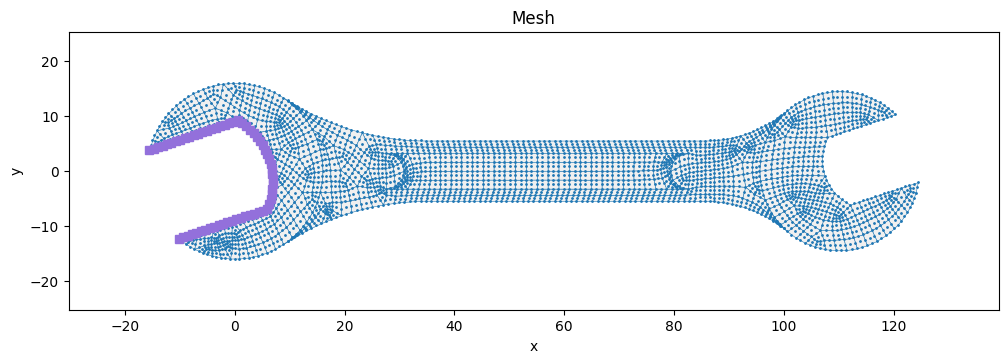

In [33]:
# Plot mesh
model.plot(
    step                = -1,
    show_node_labels    = False,
    show_element_labels = False,
    show_supports       = True,
    show_element_edges  = True,
    show_node_points    = True,
    figsize             = (12, 8),
)

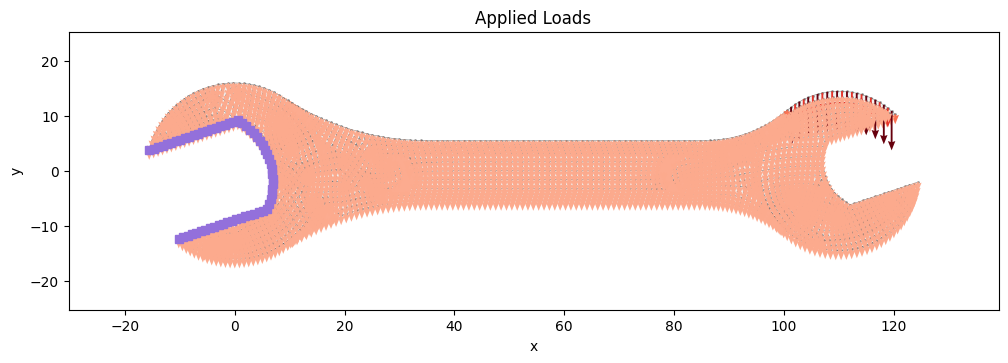

In [34]:
# Plot loads
model.plot_loads(
    show_element_edges = True,
    show_node_points   = True,
    show_supports      = True,
    figsize            = (12, 8),
)

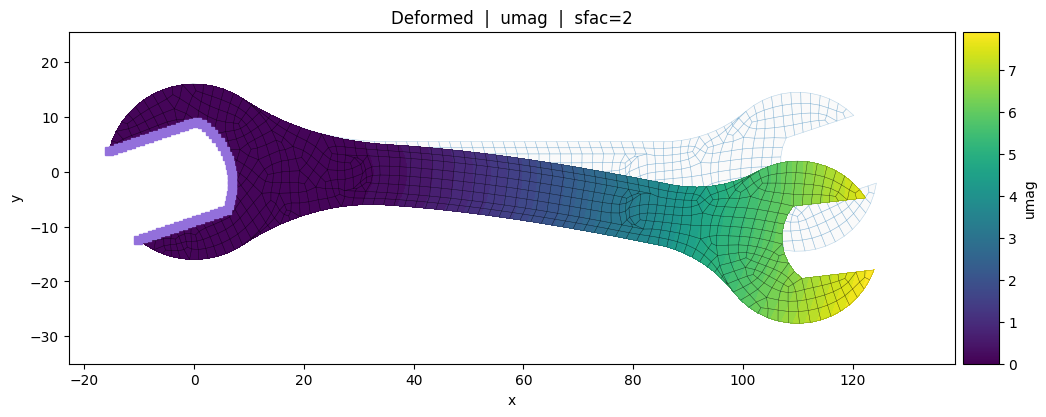

In [35]:
# Plot deformed
model.plot_deformed(
    sfac                = 2,
    step                = -1,
    component           = 'umag',   # 'ux', 'uy', 'umag'
    cmap                = 'viridis',
    show_element_edges  = True,
    show_supports       = True,
    figsize             = (12, 8),
)

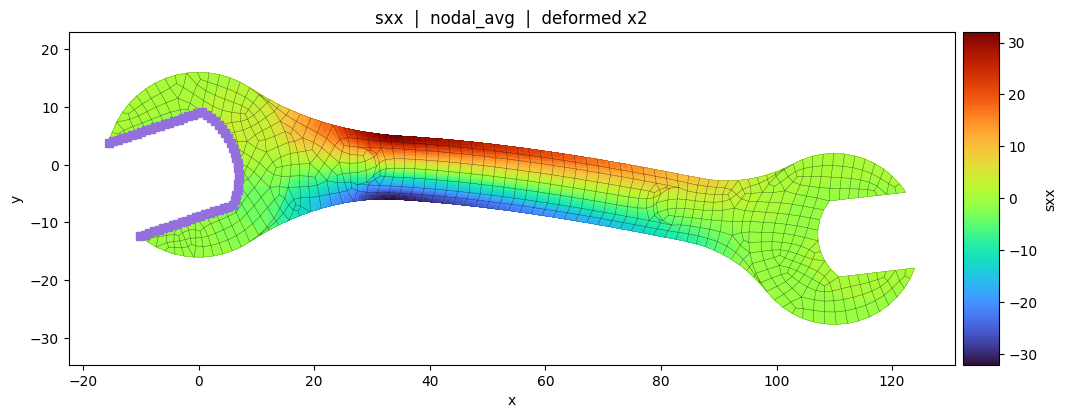

In [36]:
# Plot field
model.plot_field(
    component           = 'sxx',        # 'sxx','syy','sxy','vmis','s1','s2','exx','eyy','exy'
    source              = 'fem',
    step                = -1,
    result_type         = 'nodal_avg',  # 'nodal_avg' or 'element'
    deformed            = True,
    sfac                = 2,
    cmap                = 'turbo',
    show_element_edges  = True,
    show_supports       = True,
    figsize             = (12, 8),
)

In [37]:
# Send to gmsh — static
model.plot2gmsh(
    step            = -1,
    source         = 'fem',
    disp_factor     = 2,
    show_disp       = True,
    show_loads      = True,
    show_reactions  = True,
    show_stress     = True,
    show_strain     = True,
    show_vm         = True,
    show_averaged   = True,

)